---
title: "Conditioning & stability"
subtitle: "Lecture 3: Conditioning and stability and the start of Chapter 2: Solving nonlinear equations in 1d"
code-fold: true
format:
  html: default
  pdf: default
---

{{< include ../extras/_lecture-header.html >}}

::: {.callout-warning}

Notes for this lecture have not been updated since we met (stay tuned for updates)

:::

::: {.callout-note}

This lecture is based on Chapter 1 of [Fundamentals of Numerical Computation by Driscoll, Braun] which is avaliable <a href="https://fncbook.com/overview/" 
     class="btn btn-outline-info btn-sm" 
     target="_blank" 
     rel="noopener noreferrer">
    <i class="bi bi-archive me-1" aria-hidden="true"></i>
    online
    <span class="visually-hidden">(opens in a new tab)</span>
  </a>

:::

## Recap 

ChimeIn: floating point numbers, round off error, ... 

::: {#exr-ep-over-2}

Let $\epsilon$ be the machine precision. Is $(1 + \epsilon/2) - 1 = 1 + (\epsilon/2-1)$ in Float64?

:::

::: {.callout-tip collapse=true}
# Solution

In [134]:
#| code-fold: false 

ϵ = eps( Float64 )
(1.0 + ϵ/2) - 1.0 == 1.0 + (ϵ/2 - 1.0)

false

This is false, since $1 + \epsilon$ is the smallest float larger than $1$, Julia has to round or truncate $1 + \epsilon/2$:

In [133]:
#| code-fold: false 

1 + ϵ/2

1.0

Therefore, $(1 + \epsilon/2) -1 = 0$. On the other hand $\epsilon/2 - 1$ is a float and so $1 + (\epsilon/2 - 1)$ is not equal to $0$.

:::

::: {#exr-fp-sums}

Let $X$ be an array containing $10^{16}, -10^{16}$, and $N$ copies of $1$. What is the sum of all the entries of the array $X$? Does it depend on the order of summation? What about in ``Float64``? Why?

:::

::: {.callout-tip collapse=true}
# Solution

In [178]:
#| code-fold: false 

using Random

N = 10^2
X = vcat( [1e16, -1e16], fill(1., N) )

for _ ∈ 1:10 
    shuffle!(X)
    s = 0. 
    for x ∈ X
        s += x 
    end
    println(s)
end 

91.0
22.0
44.0
83.0
85.0
92.0
48.0
69.0
89.0
47.0


This happens because $2^{53} \leq 10^{16} < 2^{54}$ and so the spacing between floats in this interval is $2^{n-k} = 2^{53-52} = 2$ (in Float64, the binary precision is $k=52$). As a result $10^{16} + 1$ is not a float; Julia rounds this to $10^{16}$:

In [181]:
#| code-fold: false

1e16 + 1

1.0e16

:::

::: {.callout-warning} 
# Subtractive cancellation

When adding or subtracting numbers so that the result is much smaller in magnitude. For example, we know $x = -1.0000000000000000000147$ to $23$ significant digits but $x + 1 = -1.47 \times 10^{-20}$ to only $3$ significant digits. 

:::

This concept can be illustrated using (relative) condition number: 

## Conditioning

Suppose we are interested in a quantity $f(x)$ for $x\in \mathbb R$. In practice, we can only store $\widetilde{x} := \mathrm{fl}(x)$ in a computer (recall that $\widetilde{x} = x(1 + \epsilon)$ for some $|\epsilon|\leq \frac12 \epsilon_{\mathrm{mach}}$). Then the ratio of the relative error in the output to the relative error in the input in the limit as the precision goes to zero is known as the *(relative) condition number* $\kappa_f(x)$: 


::: {#def-rel-condition-number}
# Relative condition number

\begin{align}
\kappa_f(x) := \lim_{\epsilon\to0}\left|
    \frac
        {f(x) - f(x + \epsilon x)}
        {\epsilon f(x)}
    \right| \nonumber
    %
\end{align}

:::

That is, the (relative) condition number is approximately the constant of proportionality between the relative error in the output and the relative error of the input:


\begin{align}
    \left|\frac
        {f(x) - f(\widetilde{x})}
        {f(x)} \right|
    \approx \kappa_f(x) \left|\frac
        {x - \widetilde{x}}
        {x} \right|
    %
    = \kappa_f(x) |\epsilon|. \nonumber
\end{align}

::: {#exm-cond-1}

The condition number of $f(x) = x + 1$ is $\kappa_f(x) = \left|\frac{x}{x+1}\right|$. This blows up when $x\approx -1$ which explains subtractive cancellation that we mentioned above.

:::

::: {#def-illcond}

If the condition number is large, we say the problem is *ill-conditioned* or the problem is badly conditioned 

:::

Notice that 

\begin{align}
    \kappa_f(x) &= \lim_{\epsilon\to0}\left|
    \frac
        {f(x) - f(x + \epsilon x)}
        {\epsilon f(x)}
    \right| \nonumber\\
    %
    &= \lim_{\epsilon\to0}\left|
    \frac
        {f(x) - f(x + \epsilon x)}
        {\epsilon x}
    \right|
    \left| \frac{x}{f(x)} \right| \nonumber\\
    %
    &= \left| \frac{x f'(x)}{f(x)} \right|
\end{align}

::: {.box}
**Exercise**

@exr-cond-2

:::

::: {#exm-poly-roots}
# Polynomial roots as a function of monomial basis coefficients

The polynomial 

\begin{align}
    a \xi^2 + b \xi + c = 0
\end{align}

has roots $\xi_1,\xi_2$. Fix $b,c$ and consider $\xi_1 = \xi_1(a)$. What is $\kappa_{\xi_1}(a)$?

:::

::: {.callout-warning}

For higher-order polynomials, representing functions in the standard monomial basis ($\{1, x, x^2, \dots\}$) is usually a bad idea. Monomial bases are ill-conditioned; tiny perturbations in the coefficients can drastically change the behaviour of the polynomial and shift the roots significantly. To maintain numerical stability, it's a better idea to use to an orthogonal basis like Chebyshev polynomials (see later in the semester). 

Potential presentation topics include: Wilkinson’s Polynomial, conditioning of Vandermonde matrices, understand and explain [this](https://www.chebfun.org/examples/linalg/CondNos.html), [this](https://www.chebfun.org/examples/linalg/CondVandermonde.html), ....

:::

Poor conditioning is a problem with the problem! On the other hand, if we see a large error in the result, the problem might be with the solution! That is, the algorithm can also introduce errors. When the error can not be explained by an ill-conditioned problem, we will say the algorithm is *unstable*.

## Stability: An Example {#arithmetic}

Consider $\xi^2 - (10^n + 10^{-n})\xi + 1 = 0$. The roots of this equation are $\xi_1 := 10^{-n}$ and $\xi_2 := 10^n$. These roots are well separated so we expect the problem of finding the roots to be well-conditioned. We show below that the quadratic formula is ***unstable***.  

The quadratic formula in floating point arithmetic gives:

In [36]:
n = 8;
a, b, c = 1, -(10.0^n + 10.0^(-n)), 1;
ξ1, ξ2 = ( -b - sqrt( b^2 - 4*a*c) )/(2*a), ( -b + sqrt( b^2 - 4*a*c) )/(2*a);

@show ( ξ1, ξ2 ) ;

(ξ1, ξ2) = (1.4901161193847656e-8, 1.0e8)


The error in approximating the first root is quite big!

In [37]:
println( "relative errors = (", abs( ξ1 - 10.0^(-n) )/10.0^(-n) , ", ", abs( ξ2 - 10.0^n )/10.0^n, ")" )

relative errors = (0.49011611938476557, 0.0)


But why?

In [ ]:
#| code-fold: false
-b

1.0000000000000001e8

In [ ]:
#| code-fold: false
sqrt( b^2 - 4 * a * c )

9.999999999999999e7

In [ ]:
#| code-fold: false
-b - sqrt( b^2 - 4*a*c)

2.9802322387695312e-8

The error is coming from ***Subtractive Cancellation***! The quadratic formula is thus ill-conditioned. Alternatively we could compute $\xi_1$ from $\xi_2$:

In [ ]:
#| code-fold: false
ξ1 = (c/a)/ξ2

1.0e-8

Which is exact in ``Float64``.  

Another way of computing $\xi_1$ is to ***rationalise the numerator***:

\begin{align}
    \xi_1 
    &= \frac{ -b - \sqrt{ b^2 - 4ac } }{2a} \\
    %
    &= \frac{ -b - \sqrt{ b^2 - 4ac } }{2a}
    \times \frac{ -b + \sqrt{ b^2 - 4ac } }{-b + \sqrt{ b^2 - 4ac } } \nonumber\\
    %
    &= \frac
        { b^2 - ( b^2 - 4ac ) }
        {2a( -b + \sqrt{ b^2 - 4ac } )} \\
    %
    &= \frac
        { 2c }
        { -b + \sqrt{ b^2 - 4ac } }
\end{align}

Using this formula, we get

In [ ]:
#| code-fold: false
ξ1 = 2*c / ( -b + sqrt(b^2 - 4*a*c) )

1.0e-8

Which is again exact in ``Float64``

## FNC Exercises

We then looked at questions 1.4.1 and 1.4.2 from <a href="https://fncbook.com/stability/">[Fundamentals of Numerical Computation by Driscoll, Braun]</a> 

::: {#exr-FNC-1-4-1}

Exercise 1.4.1 from @fnc 

:::

::: {.callout-tip collapse=true}
# Tip

In [ ]:
#| code-fold: false
f = x -> (1 - cos(x) )/sin(x)
g = x -> 2*sin(x/2)^2/sin(x)

(f(1e-6), g(1e-6))

(5.000444502912538e-7, 5.000000000000416e-7)

:::

::: {#exr-FNC-1-4-2}

Exercise 1.4.2 from @fnc.

:::

::: {.callout-tip collapse=true}
# Tip

In [ ]:
#| code-fold: false
x = @. 10.0^(-(1:11));
f = @. (exp(x) - 1)/x;

p=1;
for n ∈ 1:8
    p = @. p + x^n/( factorial(n+1) );
end 

abs.(f-p) ./ x

11-element Vector{Float64}:
    1.1102230246251565e-14
    1.0880185641326532e-12
    4.285460875053104e-11
    4.32542890393961e-9
    9.701794922989393e-7
    3.798317216308078e-5
    0.005663214341922184
    1.1077470940534795
   82.24037095772019
  826.9037099495335
 8273.537099867668

In [46]:
# upper bound on the error between f and p as functions on x
err = @. (1/factorial(10)) * (x^9/(1-x))

11-element Vector{Float64}:
 3.061924358220656e-16
 2.7835675983824175e-25
 2.7584904128114e-34
 2.7560075231509052e-43
 2.7557594799933906e-52
 2.755734678133266e-61
 2.7557321979718108e-70
 2.755731949955909e-79
 2.755731925154322e-88
 2.7557319226741635e-97
 2.755731922426145e-106

:::

## Chapter 2. Solving nonlinear equations in 1d {#sec-chapter-2}

::: {.callout-note}

This chapter will be mainly based on Chapter 1 of @Suli.

:::

::: {#def-root}

We say $\xi$ is a **root** (or a **zero**) of $f: [a,b] \to \mathbb R$ if $f(\xi) = 0$. 

:::

* Simple functions can be solved explicitly e.g. $ax^2 + bx + c = 0$ (also true for degree $3,4$)  
* $x^5 - 4x - 2 = 0$ - no closed formula for roots of this equation

In [ ]:
#| include: false

# IF YOU HAVE DOWNLOADED THESE NOTES, 
# LET ME KNOW AND I'LL GIVE OUT 
# CHOCOLATE IN THE NEXT LECTURE

using Polynomials  
using Plots
using LaTeXStrings

p = Polynomial(-2 - 4*x + x^5)


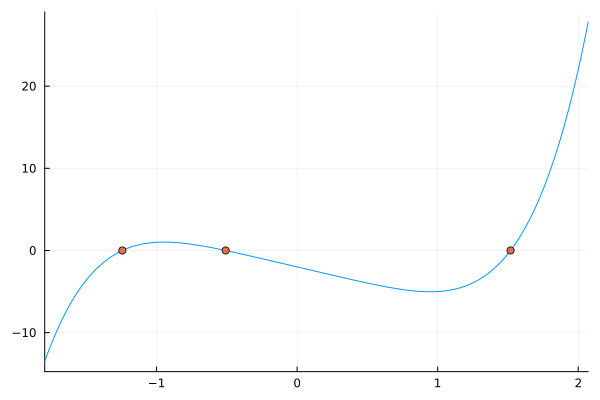

In [48]:
p = Polynomial([-2, -4, 0, 0, 0, 1]) 
@show p;

plot(p, legend=false)
plot!( real( filter( isreal, roots(p) ) ), zeros(3), seriestype=:scatter )

* Need numerical methods to get the roots!
* Aim: for $f: [a,b] \to \mathbb R$, solve $f(\xi) = 0$ for $\xi \in \mathbb R$, 
* Also, can find $\xi$ such that $f(\xi) = y$ (by considering $x \mapsto f(x) - y$) or stationary points (by considering $f = F'$),
* Simple examples with no solution, e.g. $f(x) = x^2 + 1$

::: {#thm-intermediate-value}
# Intermediate value theorem

Suppose that $f : [a,b] \to \mathbb R$ is continuous and $f(a) < y < f(b)$ or $f(b) < y < f(a)$. Then, there exists a $c\in [a,b]$ such that $f(c) = y$.

:::

This result, implies the following useful theorem for determining whether a function has a root: 

::: {#thm-change-sign}
# Change of sign

If $f$ is continuous on $[a,b]$ and $f(a) f(b) \leq 0$ then there exists $\xi \in [a,b]$ with $f(\xi) = 0$.

:::

::: {.proof}

If $f(a) f(b) = 0$ then either $a$ or $b$ is a root. We can therefore suppose that $f(a) f(b) < 0$ and so either $f(a) < 0 < f(b)$ or $f(b) < 0 < f(a)$. Since $f$ is continuous, we can apply the intermediate value theorem on $f$ to conclude there exists a root $c \in [a,b]$. 

:::

::: {.callout-warning}

The converse to this theorem is untrue. i.e. there exists $f$ with a real root in $[a,b]$ but with $f(a)f(b) > 0$.

:::

::: {#exr-change-sign-1}

Let $f(x) = e^x - 2x - 1$. Apply change of sign theorem to $f$ to conclude there exists $\xi \in [1,2]$ such that $f(\xi) = 0$.

:::

(f(1), f(2)) = (-0.2817181715409549, 2.3890560989306504)


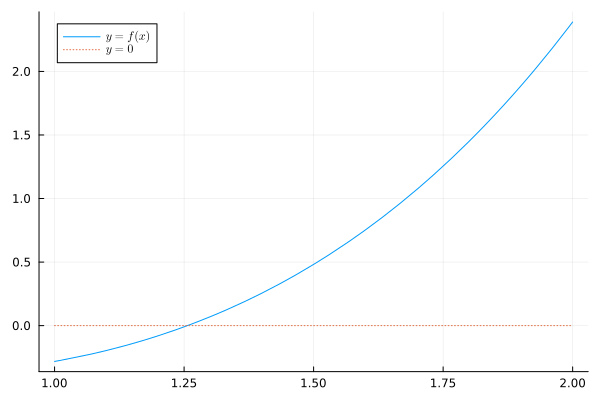

In [16]:
f = x -> exp(x) - 2*x - 1;
@show ( f(1), f(2) )

plot( f, 1, 2; label = L"y = f(x)" )
plot!( x->0; label = L"y = 0", linestyle=:dot )

::: {#def-fixed-point}

We say $\xi$ is a **fixed point** of $g: [a,b] \to \mathbb R$ if $g(\xi) = \xi$. 

:::

* We can rewrite $f(\xi) = 0$ as a fixed point problem $g(\xi) = \xi$ (for example, we could define $g(x) := x \pm f(x)$).

The change of sign theorem can be applied here:

::: {#thm-Brouwer}
# Brouwer's fixed point theorem 

Suppose $g : [a,b]\to\mathbb R$ is continuous with $g(x) \in [a,b]$ for all $x \in [a,b]$. Then, there exists $\xi\in [a,b]$ with $g(\xi) = \xi$. 

::: 

::: {.proof} 

We can apply the change of sign theorem to $f(x) := g(x) - x$. Indeed, because $g(a), g(b) \in [a,b]$, we have $f(a) = g(a) - a \geq 0$ and $f(b) = g(b) - b \leq 0$ and thus $f$ is continuous with $f(a) f(b) \leq 0$. All roots $\xi\in[a,b]$ of $f$ are fixed points of $g$.

:::

::: {#exr-change-sign-2}

Let's return to @exr-change-sign-1. You showed that $f(x) = e^x - 2x - 1$ has a root $\xi \in [1,2]$. 

Show that $f(x) = 0$ can be solved by instead considering the fixed point problems $g(x) = x$ or $h(x) = x$ where

$$
\begin{align}
    g(x) = \log( 2x + 1 ), \quad  \text{and} \quad h(x) = \frac{e^x - 1}{2}
\end{align}
$$ {#eq-L3-g-h}

Show that Brouwer's fixed point theorem applies to $g$ but **not** $h$ on $[1,2]$.

:::

(g(1), g(2)) = (1.0986122886681098, 1.6094379124341003)
(h(1), h(2)) = (0.8591409142295225, 3.194528049465325)


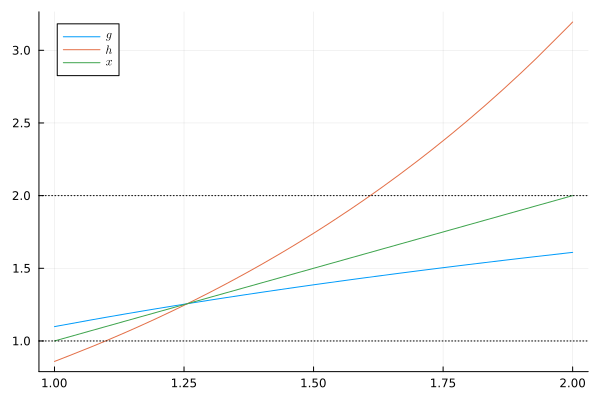

In [49]:
g = x -> log( 2*x + 1 );    
h = x -> (exp(x) - 1)/2;
id = x -> x;

@show (g(1), g(2));
@show (h(1), h(2));

plot( [g, h, id], 1, 2, label=[L"g" L"h" L"x"])
hline!(  [1, 2]; linestyle=:dot, color=:black, primary=false )

## Simple iterations

Suppose we want to find fixed points of a continuous function $g:[a,b] \to [a,b]$. The **simple iteration** is defined by

$$
\begin{align}
    x_1 &\in [a,b] \nonumber\\
    %
    x_{n+1} &:= g(x_n).
\end{align}
$$ {#eq-simple-iteration}

::: {#lem-simple-1}

Suppose that $(x_{n}) \to \xi$ then $\xi$ is a fixed point of $g$.

::: 

::: {.proof} 

Since $(x_{n+1}) \to \xi$, we have $\xi = \lim_{n\to \infty} g(x_n) = g(\xi)$ by continuity of $g$.

:::

::: {#exm-change-sign-3}

Returning to @exr-change-sign-1 and @exr-change-sign-2 where $f(x) = e^x - 2x - 1$. Recall that finding roots of $f$ in $[1,2]$ is equivalent to finding fixed points of $g$ and $h$ as defined in @eq-L3-g-h. 

Let's see if the iterative methods $x_{n+1} = g(x_n)$ and $y_{n+1} = h(y_n)$ converge for $x_1 = y_1 = 1$: 


(x[end], y[end]) = (1.256431208625988, 6.439293542825908e-15)


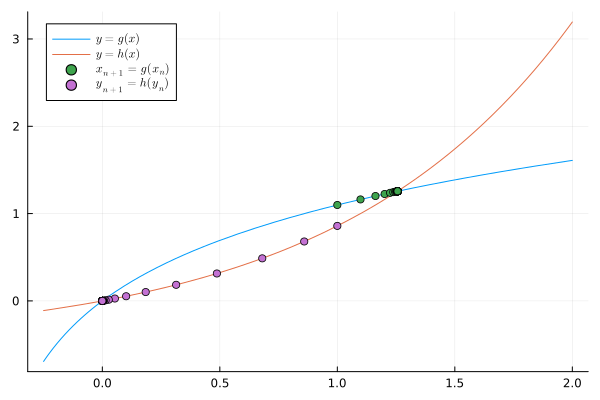

In [50]:
n_max = 15
x, y = [1.], [1.]
for n ∈ 1:50
    push!( x, g(x[end])) 
    push!( y, h(y[end])) 
end
@show (x[end], y[end]);

plot( [g, h] , -0.25, 2, label=[ L"y = g(x)" L"y = h(x)"])
plot!( x, g.(x), seriestype=:scatter, label=L"x_{n+1} = g(x_n)" )
plot!( y, h.(y), seriestype=:scatter, label=L"y_{n+1} = h(y_n)" )

Here, we see that $x_n \to \xi \approx 1.26 \in [1,2]$ but $y_{n} \to \widetilde{\xi} \approx 0$ so the formulations $g(x) = x$ and $h(x) = x$ are equivalent, but they lead to different numerical methods.

In fact, $(\xi, \tilde{\xi})$ approximate the two real roots of $f$:

(f(1), f(2)) = (-0.2817181715409549, 2.3890560989306504)


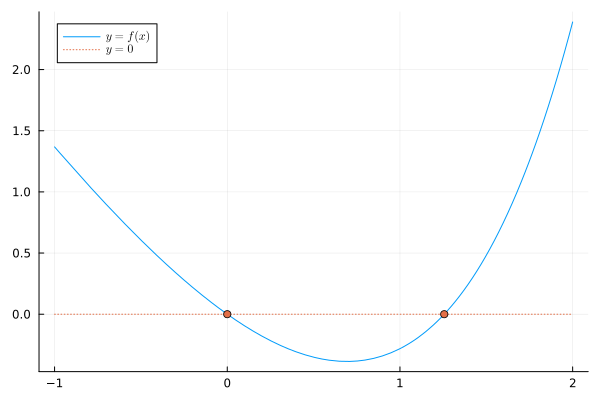

In [51]:
f = x -> exp(x) - 2*x - 1;
@show ( f(1), f(2) )

plot( f, -1, 2; label = L"y = f(x)" )
plot!( x->0; label = L"y = 0", linestyle=:dot )
scatter!( [x[end], y[end]], [0, 0]; primary=false )

:::

::: {#def-order-of-convergences}
# Order of convergence

Let $x_n \to \xi$. Suppose that there exist $\alpha\geq1$ and $\mu \geq 0$ such that

\begin{align}
    \lim_{n\to\infty}  \frac{\left|x_{n+1} - \xi\right|}{\left|x_n - \xi\right|^\alpha} = \mu
\end{align}

* If $\alpha = 1$ and $\mu \in (0,1)$, we say the convergence is *linear*,
* If $\alpha = 1$ but $\mu = 0$, we say the convergence is *superlinear* (i.e. faster than linear),
* If $\alpha = 1$ and $\mu = 1$, we say the convergence is *sublinear* (i.e slower than linear),
* If $\alpha = 2$, we say the convergence is *quadratic*,...

In the case where *(i)* $\alpha = 1, \mu \in (0,1)$ or *(ii)* $\alpha>1, \mu> 0$, we say

* $x_n \to \xi$ with *order* $\alpha$, 
* $\mu$ is the *asymptotic error constant*, and
* $\rho := - \log_{10} \mu$ is the *asymptotic rate of convergence*.

:::

* Define the errors $e_n := |x_{n}-\xi|$. Then, we have $e_{n+1} \approx \mu e_{n}^\alpha$,
* For linear convergence, $e_{N+1} \approx \mu e_N = 10^{-\rho} e_N$ and so $\rho$ measures the number of decimal digits of accuracy gained in one iteration (for sufficiently large $N$).

::: {#exm-change-sign-4}

Let's go back to our example: $f(x) = e^x - 2x - 1$. We have defined $g(x) = \log( 2x + 1 )$ and we are trying to solve the fixed point problem $g(x) = x$. 

(This is mathematically equivalent to $f(x) = 0$.)

We have seen (numerically) that $x_{n+1} = g(x_n)$ with $x_1$ converges to $\xi = g(\xi) \approx 1.26$. What is the order of convergence? What is the asymptotic error constant? Asymptotic rate of convergence?

:::

(It turns out that $\xi = g(\xi)$ can be written in terms of the LambertW function.)

In [56]:
using LambertW 
ξ = -( 1/2 + lambertw(-(1/2) * exp(-1/2), -1) )
println("ξ = $ξ")

ξ = 1.2564312086261695


In [57]:
μₙ = @. abs( ( x[2:end] - ξ )/(x[end-1] - ξ ) )
μ, ρ = μₙ[end], -log10( μₙ[end] )
println("μ = $μ")
println("ρ = $ρ")

μ = 0.5692414752957551
ρ = 0.24470346446290264


Since ``μₙ``  appears to converge to $\mu \in (0,1)$, we have $x_n \to \xi$ linearly with asymptotic error constant $\mu\approx 0.569$ and asymptotic rate of convergence $\rho \approx 0.245$. Next time, we will prove (mathematically) that $x_{n+1} = g(x_n)$ converges linearly and show that $\mu = |g'(\xi)|$. Our computed value of $\mu$ (after $15$ iterations) is close to this theoretical value: 

In [54]:
g′ = x -> 2/( 2*x + 1);
@show g′( ξ );

g′(ξ) = 0.569336274081677


:::{.callout-tip}
# TO-DO

* Assignment 1: Due today!
* Exercises throughout the notes,
* Extra reading: [myths of polynomial interpolation](https://people.maths.ox.ac.uk/trefethen/mythspaper.pdf)
* (Sign-up to office hours if you like)

:::